In [ ]:
import pandas as pd
import numpy as np
import os 
matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams['font.family'] = 'Arial'
import schicluster
PACKAGE_DIR = schicluster.__path__[0]

In [2]:
age_colors = {
    '2T': '#30123b',
    '3T': '#2a92e5',
    '1m': '#27e37b',
    '4-7m': '#f6d531',
    'adult': '#aa40fc'
}

In [3]:
cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)

/tmp/ipykernel_3376271/286891771.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)


In [4]:
file_list = glob.glob('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_distance/*_cis_trans.tsv')

df_list = [pd.read_csv(f, sep='\t') for f in file_list]
cell_contacts_count = pd.concat(df_list, ignore_index=True)


cell_contacts_count.set_index('Cell', inplace=True)
cell_contacts_count.index.names = ['ID']
cell_contacts_count = cell_contacts_count.drop_duplicates()

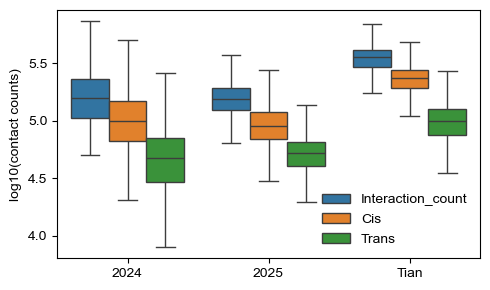

In [5]:
cellID_merged['BATCH'] = cellID_merged['dataBatch'].map({'oPFC':'2024','oHPC':'2024','new':'2025','old':'2024','Tien':'Tian'})
cellID_merged = cellID_merged.join(cell_contacts_count, on='ID', how='inner')

df = cellID_merged.melt(
    id_vars="BATCH",
    value_vars=['Interaction_count',"Cis", "Trans",],
    var_name="Metric",
    value_name="Value"
)

# log10 transform the data
df["log10_Value"] = np.log10(df["Value"])

plt.figure(figsize=(5, 3))
sns.boxplot(
    data=df,
    x="BATCH",
    y="log10_Value",
    # y = 'Value',
    hue="Metric",
    showfliers=False
)

plt.xlabel("")
plt.ylabel("log10(contact counts)")
plt.legend(title="", frameon=False)
plt.tight_layout()

In [6]:
contact_distance_path = '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_distance'

In [7]:
contact_distance_files = glob.glob(f'{contact_distance_path}/*distance_decay.hdf5')

contact_distance = [pd.read_hdf(file) for file in contact_distance_files]
contact_distance = pd.concat(contact_distance,axis = 0)
contact_distance.drop_duplicates(inplace = True)

In [8]:
UMAP_embedding = pd.read_csv('/cndd2/hex002/Luo_Development/joint_umap_coords.csv', index_col=[0], names=['joint_embedding_UMAP1', 'joint_embedding_UMAP2'], skiprows=1)
cellID_merged = cellID_merged.merge(UMAP_embedding, left_index=True, right_index=True, how='left')

## Contact Distance

In [14]:
contact_distance_path = '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_distance'
contact_distance_files = glob.glob(f'{contact_distance_path}/*distance_decay.hdf5')

contact_distance = [pd.read_hdf(file) for file in contact_distance_files]
contact_distance = pd.concat(contact_distance,axis = 0)
contact_distance.drop_duplicates(inplace = True)

In [15]:
contact_distance = contact_distance[contact_distance.index.isin(cellID_merged.index)]

In [16]:
def bin_to_size(bin_number):
    size_kb = 2.5 *2 ** ((bin_number) * 0.125) 
    if size_kb >= 1000:
        return f"{size_kb / 1000:.0f} Mb"  
    else:
        return f"{size_kb:.0f} kb"  

In [17]:
normalized_contact_distance = contact_distance.div(contact_distance.sum(axis=1), axis=0)
normalized_contact_distance = cellID_merged.merge(
    normalized_contact_distance, left_index=True, right_index=True, how="right"
)

### Calculate SE/LE ratio

In [18]:
X = normalized_contact_distance.drop_duplicates().iloc[:,-132:].copy()

# Ensure bin numbers are numeric
bin_nums = pd.to_numeric(X.columns, errors='coerce')
valid = ~bin_nums.isna()
X = X.loc[:, valid]
bin_nums = bin_nums[valid].astype(float)

left_bp  = 2500.0 * 2**(0.125 * bin_nums.values)
right_bp = 2500.0 * 2**(0.125 * (bin_nums.values + 1.0))

# ranges in bp
SE_lo, SE_hi = 200_000.0, 2_000_000.0         # 200 kb–2 Mb
LE_lo, LE_hi = 20_000_000.0, 100_000_000    # 20–100 Mb

def fmt_bp_label(x):
    if x >= 1_000_000:
        return f"{x / 1_000_000:g} Mb"
    return f"{x / 1_000:g} kb"

se_le_axis_label = (
    f"log$_2$(SE: {fmt_bp_label(SE_lo)}-{fmt_bp_label(SE_hi)} / "
    f"LE: {fmt_bp_label(LE_lo)}-{fmt_bp_label(LE_hi)})"
)

SE_mask = (right_bp > SE_lo) & (left_bp < SE_hi)
LE_mask = (right_bp > LE_lo) & (left_bp < LE_hi)

# Sum across selected columns per row
SE_sum = X.loc[:, SE_mask].sum(axis=1)
LE_sum = X.loc[:, LE_mask].sum(axis=1)

# Ratio (avoid divide-by-zero)
ratio = SE_sum / LE_sum.replace(0, np.nan)

# Attach back
sorted_df_ratio = normalized_contact_distance.drop_duplicates().copy()
sorted_df_ratio["SE_sum_200kb_2Mb"]   = SE_sum
sorted_df_ratio["LE_sum_20Mb_100Mb"]  = LE_sum
sorted_df_ratio["SE_over_LE_ratio"]   = ratio
sorted_df_ratio["log2_SE_over_LE_ratio"]   = np.log2(ratio)

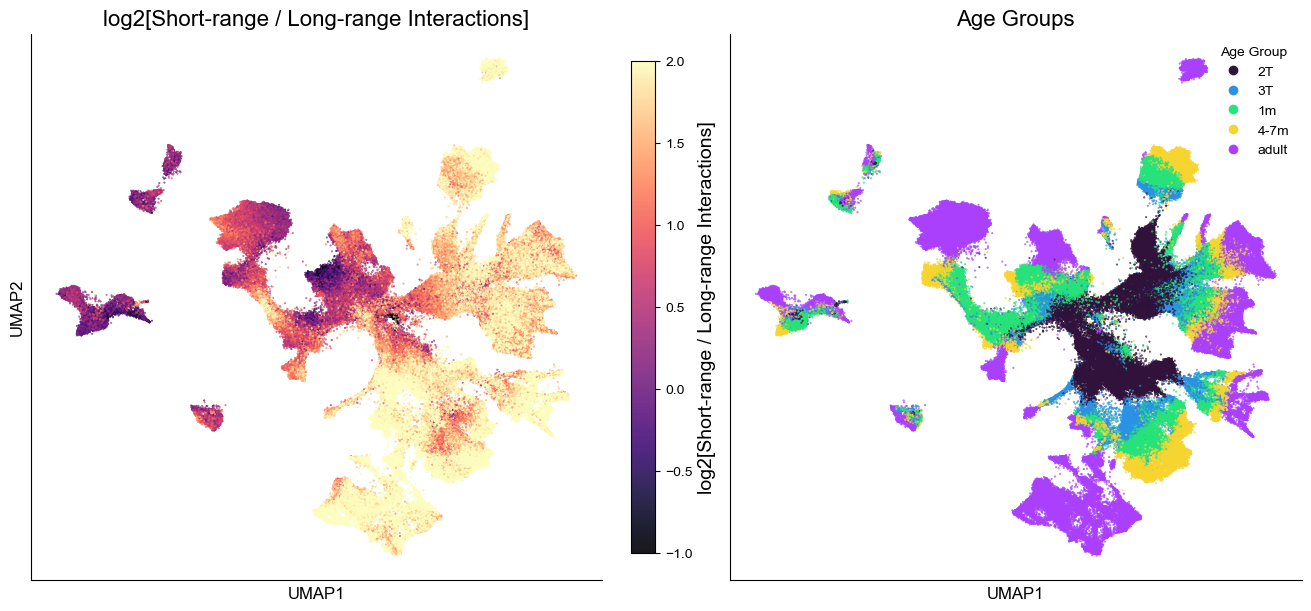

In [19]:
# Increase figure size
color_map = sorted_df_ratio['age_groups'].map(age_colors)

# Create figure with two columns
fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

# === (1) log2[Short-range / Long-range Interactions] ===
sc1 = axes[0].scatter(
    x=sorted_df_ratio['joint_embedding_UMAP1'],
    y=sorted_df_ratio['joint_embedding_UMAP2'],
    c=sorted_df_ratio['log2_SE_over_LE_ratio'],
    cmap='magma',
    alpha=0.9,
    vmin=-1,vmax = 2,
    rasterized=True,
    s=0.2
)
cbar1 = fig.colorbar(sc1, ax=axes[0], shrink=0.9)
cbar1.set_label('log2[Short-range / Long-range Interactions]', fontsize=14)
axes[0].set_title('log2[Short-range / Long-range Interactions]', fontsize=16)
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_xlabel('UMAP1', fontsize=12)
axes[0].set_ylabel('UMAP2', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)


# === (2) Age groups ===
sc2 = axes[1].scatter(
    x=sorted_df_ratio['joint_embedding_UMAP1'],
    y=sorted_df_ratio['joint_embedding_UMAP2'],
    c=color_map,
    alpha=0.9,
    rasterized=True,
    s=0.2
)
axes[1].set_title('Age Groups', fontsize=16)
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].set_xlabel('UMAP1', fontsize=12)
axes[1].spines[['top','right']].set_visible(False)

# Legend for age groups
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=age,
               markerfacecolor=col, markersize=8)
    for age, col in age_colors.items()
]
axes[1].legend(handles=handles, title='Age Group', loc='best', frameon=False, fontsize=10)
# plt.savefig('SE_LE_ratio_umap_age.pdf', dpi=200)
plt.show()

In [20]:
plot_dict_neurons = {
    "MSN":    [('L2', 'MSN', '2T'),  ('L2', 'MSN', '3T'),  ('L2', 'MSN', '1m'),  ('L2', 'MSN', '4-7m'),  ('L2', 'MSN', 'adult')],
    "CGE":    [('L3', 'eCGE', '2T'),  ('L2', 'CGE', '3T'),  ('L2', 'CGE', '1m'),  ('L2', 'CGE', '4-7m'),  ('L2', 'CGE', 'adult')],
    "MGE":    [('L3', 'MGE', '2T'),   ('L2', 'MGE', '3T'),  ('L2', 'MGE', '1m'),  ('L2', 'MGE', '4-7m'),  ('L2', 'MGE', 'adult')],
    
    "UL":     [('L2', 'UL', '2T'),    ('L2', 'UL', '3T'),   ('L2', 'UL', '1m'),   ('L2', 'UL', '4-7m'),   ('L2', 'UL', 'adult')],
    "DL/ENT": [('L2', 'DL/ENT', '2T'),('L2', 'DL/ENT', '3T'),('L2', 'DL/ENT', '1m'),('L2', 'DL/ENT', '4-7m'),('L2', 'DL/ENT', 'adult')],
    "CA": [('L2', 'CA', '2T'),('L2', 'CA', '3T'),('L2', 'CA', '1m'),('L2', 'CA', '4-7m'),('L2', 'CA', 'adult')],
    
}
plot_dict_glia = {
    "GPC":    [('L3', 'GPC', '2T'),  ('L3', 'GPC', '3T'),  ('L3', 'GPC', '1m'),],
    "OPC":    [('L3', 'OPC', '2T'),  ('L3', 'OPC', '3T'),  ('L3', 'OPC', '1m'),  ('L3', 'OPC', '4-7m'),  ('L3', 'OPC', 'adult')],
    "ODC":    [('L3', 'ODC', '2T'),  ('L3', 'ODC', '3T'),  ('L3', 'ODC', '1m'),  ('L3', 'ODC', '4-7m'),  ('L3', 'ODC', 'adult')],
    "Ast":    [('L3', 'Astro', '2T'),  ('L3', 'Astro', '3T'),  ('L3', 'Astro', '1m'),  ('L3', 'Astro', '4-7m'),  ('L3', 'Astro', 'adult')],
    "MGC-1":    [('L3', 'MGC-1', '3T'), ('L3', 'MGC-1', '1m'),  ('L3', 'MGC-1', '4-7m'),  ('L3', 'MGC-1', 'adult')],
    "MGC-2":    [ ('L3', 'MGC-2', '1m'),  ('L3', 'MGC-2', '4-7m'),  ('L3', 'MGC-2', 'adult')],
    
}

In [29]:
import importlib

import plot_function

importlib.reload(plot_function)

from plot_function import *

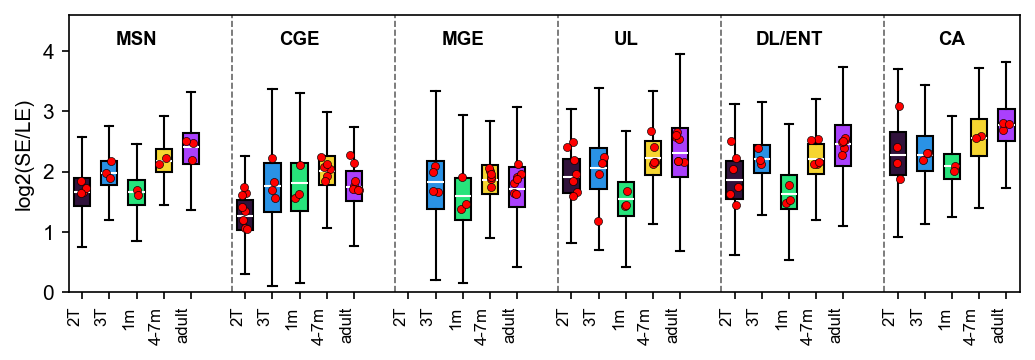

In [22]:
fig, stats = ratio_by_groups_scatter(sorted_df_ratio, plot_dict_neurons, age_col='age_groups',figsize=(7/6 * len(plot_dict_neurons),2.5), min_cells_per_tuple=150, age_color_map=age_colors,ylim = [0,4])
# plt.savefig('/cndd2/hex002/Luo_Development/hic_contact_dist/Neuron_allData_donor.pdf', dpi=200)

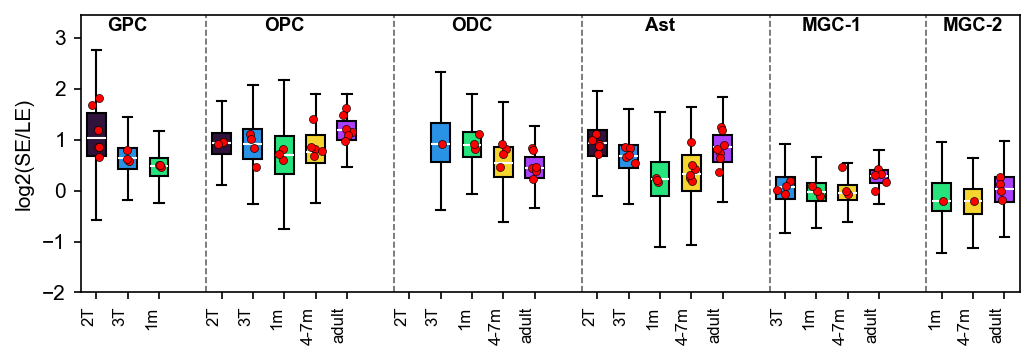

In [ ]:
fig, stats = ratio_by_groups_scatter(sorted_df_ratio, plot_dict_glia, age_col='age_groups',figsize=(7/6 * len(plot_dict_glia),2.5), min_cells_per_tuple=150, age_color_map=age_colors,ylim = [-2,3])
# plt.savefig('/cndd2/hex002/Luo_Development/hic_contact_dist/Glia_allData_donor.pdf', dpi=200)

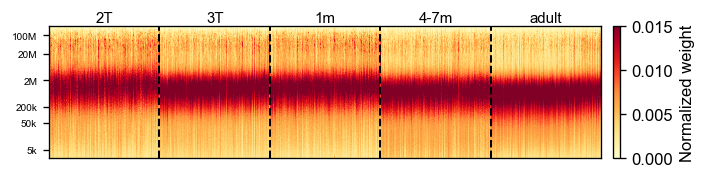

In [32]:
fig, ax = heatmap_by_L2_peak_balanced(normalized_contact_distance.drop_duplicates().iloc[:,-132:],normalized_contact_distance, L2 = 'MSN',cmap = 'YlOrRd',balance = True, split_by_region =False)#,min_cells_per_age=200)

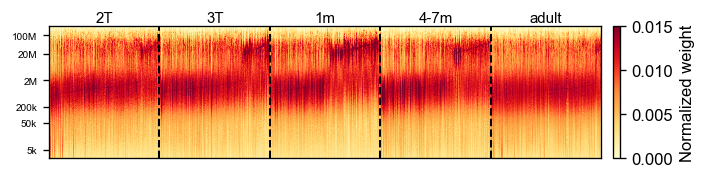

In [34]:
fig, ax = heatmap_by_L2_peak_balanced(normalized_contact_distance.drop_duplicates().iloc[:,-132:],normalized_contact_distance, L2='OPC',cmap = 'YlOrRd',balance = True, split_by_region =False)#,min_cells_per_age=200)